In [2]:
#CONEXIÓN SEGURA A MONGODB ATLAS (COLECCIÓN PROCESADA)

from pyspark.sql import SparkSession
import os

# se cargan las variables de entorno inyectadas por Docker desde el .env
mongo_uri = os.getenv("MONGO_URI")
db_name = os.getenv("MONGO_DB_NAME")
collection_processed = os.getenv("MONGO_COLLECTION_PROCESSED")

# Inicializa la sesión con el conector de Mongo
spark = SparkSession.builder \
    .appName("EDA_Inmobiliario_Coquimbo_Oficial") \
    .config("spark.mongodb.read.connection.uri", mongo_uri) \
    .config("spark.mongodb.read.database", db_name) \
    .config("spark.mongodb.read.collection", collection_processed) \
    .config("spark.jars.packages", "org.mongodb.spark:mongo-spark-connector_2.12:10.3.0") \
    .getOrCreate()

# Cargamos el DataFrame oficial
df_raw = spark.read.format("mongodb").load()

print(f"¡Conexión Exitosa! Registros totales pre-procesados: {df_raw.count()}")
print("\n Esquema de datos oficial recibido:")
df_raw.printSchema()

¡Conexión Exitosa! Registros totales pre-procesados: 1926

 Esquema de datos oficial recibido:
root
 |-- _id: string (nullable = true)
 |-- banos: integer (nullable = true)
 |-- dormitorios: integer (nullable = true)
 |-- enlace: string (nullable = true)
 |-- estacionamiento: integer (nullable = true)
 |-- fecha_extraccion: string (nullable = true)
 |-- gimnasio: integer (nullable = true)
 |-- imagen: string (nullable = true)
 |-- lavanderia: integer (nullable = true)
 |-- m2: integer (nullable = true)
 |-- piscina: integer (nullable = true)
 |-- precio: integer (nullable = true)
 |-- quincho: integer (nullable = true)
 |-- responsable: string (nullable = true)
 |-- terraza: integer (nullable = true)
 |-- titulo: string (nullable = true)
 |-- ubicacion: string (nullable = true)



In [4]:
# ==============================================================================
# PREPARACIÓN DE DATOS E INGENIERÍA DE ATRIBUTOS
# ==============================================================================
from pyspark.sql import functions as F

# 1. Creamos el IDH y fabricamos la columna macro 'ciudad_limpia' desde el texto de ubicación
df_kpi = df_raw.filter(F.col("banos") > 0) \
    .withColumn("IDH", F.round(F.col("dormitorios") / F.col("banos"), 1)) \
    .withColumn("ciudad_limpia", 
        F.when(F.lower(F.col("ubicacion")).contains("coquimbo"), "Coquimbo")
         .otherwise("La Serena")
    )

# 2. Seleccionamos estrictamente lo necesario para el KPI (Optimiza la memoria de tu Docker)
df_kpi_reducido = df_kpi.select("ciudad_limpia", "precio", "IDH")

In [5]:
# ==============================================================================
# CLASIFICACIÓN DE CARTERA Y PASO A PANDAS
# ==============================================================================
import pandas as pd

# 1. Clasificamos según la regla del KPI del Gerente de Riesgo
df_riesgo = df_kpi_reducido.withColumn(
    "Categoria_Riesgo",
    F.when(F.col("IDH") == 1.0, "Óptimo (IDH 1.0)")
     .when(F.col("IDH") >= 2.0, "Hacinado (IDH >= 2.0)")
     .otherwise("Excluido") # Ignora valores intermedios (ej: 1.3 o 0.7) para aislar la brecha pura
)

# 2. Filtramos y enviamos a Pandas de forma segura
df_pandas_bch = df_riesgo.filter(F.col("Categoria_Riesgo") != "Excluido").toPandas()

# 3. Limpieza numérica estricta del precio
df_pandas_bch['precio'] = pd.to_numeric(df_pandas_bch['precio'], errors='coerce')
df_pandas_bch = df_pandas_bch.dropna(subset=['precio'])

In [6]:
# ==============================================================================
# EXTRACTOR SEMESTRAL DEL KPI: BRECHA DE CONFORT HIGIÉNICO (BCH)
# ==============================================================================

# 1. Agrupamos por la nueva segmentación de comunas
resumen_kpi = df_pandas_bch.groupby(['ciudad_limpia', 'Categoria_Riesgo'])['precio'].mean().unstack()

# 2. Aplicamos la fórmula del KPI (Hacinado - Óptimo = Pérdida de valor)
resumen_kpi['Brecha_BCH'] = resumen_kpi['Hacinado (IDH >= 2.0)'] - resumen_kpi['Óptimo (IDH 1.0)']

# 3. Formateamos como moneda para la mesa de directores
resumen_kpi_formateado = resumen_kpi.copy()
for col in resumen_kpi_formateado.columns:
    resumen_kpi_formateado[col] = resumen_kpi_formateado[col].apply(lambda x: f"${x:,.0f}")

print("=== REPORTE EJECUTIVO SEMESTRAL DE RIESGO ===")
print(resumen_kpi_formateado)

=== REPORTE EJECUTIVO SEMESTRAL DE RIESGO ===
Categoria_Riesgo Hacinado (IDH >= 2.0) Óptimo (IDH 1.0) Brecha_BCH
ciudad_limpia                                                     
Coquimbo                      $483,131         $547,165   $-64,034
La Serena                     $498,303         $595,544   $-97,240


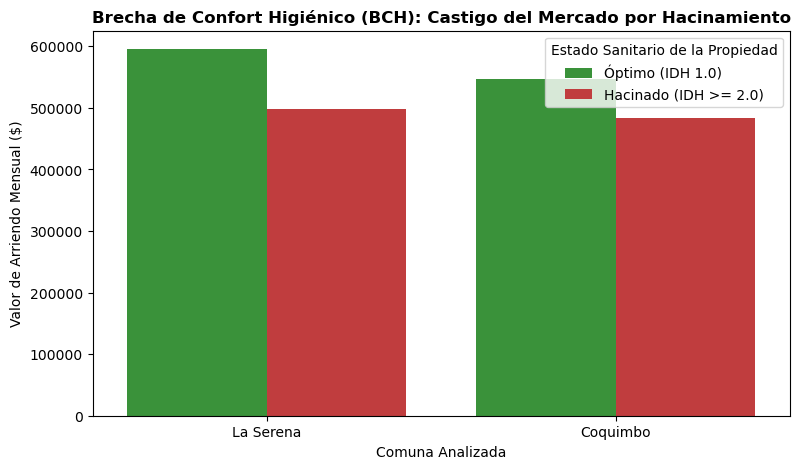

¡Datos exportados y listos para Streamlit en la carpeta Semana 15!


In [9]:
# ==============================================================================
# VISUALIZACIÓN DE LA BRECHA FINANCIERA (BCH)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df_pandas_bch,
    x='ciudad_limpia',
    y='precio',
    hue='Categoria_Riesgo',
    palette=['#2ca02c', '#d62728'], # Verde (Estable) vs Rojo (Peligro)
    errorbar=None
)

plt.title('Brecha de Confort Higiénico (BCH): Castigo del Mercado por Hacinamiento', fontsize=12, fontweight='bold')
plt.xlabel('Comuna Analizada', fontsize=10)
plt.ylabel('Valor de Arriendo Mensual ($)', fontsize=10)
plt.legend(title='Estado Sanitario de la Propiedad')
plt.ticklabel_format(style='plain', axis='y')

plt.show()

# ==============================================================================
# EXPORTAR DATOS PARA STREAMLIT
# ==============================================================================

df_pandas_bch.to_csv("/home/jovyan/work/semanas/Semana 15/datos_riesgo_inmobiliario_dashboard.csv", index=False)

# Guardamos también el resumen pequeñito para tenerlo a mano por si acaso
resumen_kpi.to_csv("/home/jovyan/work/semanas/Semana 15/tabla_resumen_bch.csv")

print("¡Datos exportados y listos para Streamlit en la carpeta Semana 15!")

# Insights Estratégicos del KPI BCH (Gerencia de Riesgos)


Medición de Pérdida de Capital: El indicador BCH demuestra con datos actualizados de la conurbación que adquirir un activo con hacinamiento sanitario (IDH >= 2.0) genera una pérdida mensual directa en la capacidad de cobro de -$64.034 en Coquimbo y un severo castigo de -$97.240 en La Serena por cada propiedad expuesta.
Tolerancia Geográfica: Se detecta que el mercado de La Serena es mucho más intolerante al déficit higiénico, penalizando la propiedad con casi 100 mil pesos mensuales de diferencia frente a un activo óptimo, lo que destruye el flujo de caja proyectado del fondo.
Regla de Negocio (Mitigación): Para el semestre en curso, se instruye al comité de inversiones vetar la compra de carteras inmobiliarias o la aprobación de planos que incluyan configuraciones familiares dependiendo de un solo baño (ej: 2D/1B o 3D/1B). En caso de presentarse una oportunidad de compra de este tipo, el equipo negociador está obligado a exigir un descuento equivalente a la pérdida anualizada del BCH para proteger la rentabilidad del portafolio.